# MovieIQ — Predictive Analytics on Film Success

## Stage 0: Problem Statement

**Success definition:** A movie is labeled successful if `revenue > budget`.

**Why it matters:** Studios and investors can use this to inform greenlighting/funding decisions before committing money.

**Problem type:** Binary classification — target variable is `success` (1 = success, 0 = failure).

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

## Stage 1: Data Preparation

In [2]:
df = pd.read_csv("movies.csv")
df.head()

,budget,revenue,popularity,runtime,vote_average,title,genres
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]"
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]"
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]"
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]"
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]"


In [3]:
df.shape

(2000, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        2000 non-null   int64  
 1   revenue       2000 non-null   int64  
 2   popularity    2000 non-null   float64
 3   runtime       2000 non-null   int64  
 4   vote_average  2000 non-null   float64
 5   title         2000 non-null   object 
 6   genres        2000 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 109.5+ KB


In [5]:
df.describe()

,budget,revenue,popularity,runtime,vote_average
count,2.000000e+03,2.000000e+03,2000.000000,2000.000000,2000.000000
mean,1.019211e+08,1.780574e+08,50.090738,129.568000,6.036764
std,5.682795e+07,1.293879e+08,28.482104,28.906507,1.743093
min,1.070640e+06,1.138729e+06,1.018466,80.000000,3.008133
25%,5.274832e+07,7.458306e+07,25.720784,104.000000,4.583298
50%,1.026023e+08,1.484882e+08,50.210396,130.000000,6.052901
75%,1.507962e+08,2.623679e+08,74.925354,155.000000,7.577305
max,1.999879e+08,5.744901e+08,99.764659,179.000000,8.998509


In [6]:
# Check for missing values and zero budget/revenue
print(df.isnull().sum())
print("Movies with Budget = 0:", (df["budget"] == 0).sum())
print("Movies with Revenue = 0:", (df["revenue"] == 0).sum())

budget          0
revenue         0
popularity      0
runtime         0
vote_average    0
title           0
genres          0
dtype: int64
Movies with Budget = 0: 0
Movies with Revenue = 0: 0


In [7]:
# Create the target variable
df["success"] = (df["revenue"] > df["budget"]).astype(int)
df["success"].value_counts(normalize=True) * 100

success
1    80.7
0    19.3
Name: proportion, dtype: float64

In [8]:
# Parse genres (stored as a stringified list of dicts)
df["genres"] = df["genres"].apply(ast.literal_eval)
df["genre_names"] = df["genres"].apply(lambda x: [g["name"] for g in x])
df[["genres", "genre_names"]].head()

,genres,genre_names
0,"[{'id': 10749, 'name': 'Romance'}]",[Romance]
1,"[{'id': 18, 'name': 'Drama'}]",[Drama]
2,"[{'id': 35, 'name': 'Comedy'}]",[Comedy]
3,"[{'id': 18, 'name': 'Drama'}]",[Drama]
4,"[{'id': 35, 'name': 'Comedy'}]",[Comedy]


## Stage 2: Exploratory Data Analysis (EDA)

### Budget vs Revenue

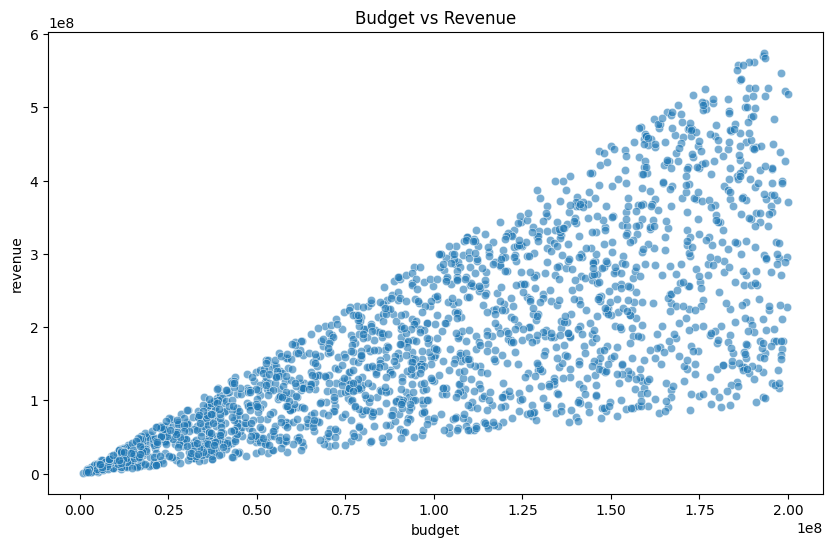

In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="budget", y="revenue", alpha=0.6)
plt.title("Budget vs Revenue")
plt.show()

### Most Common Genres

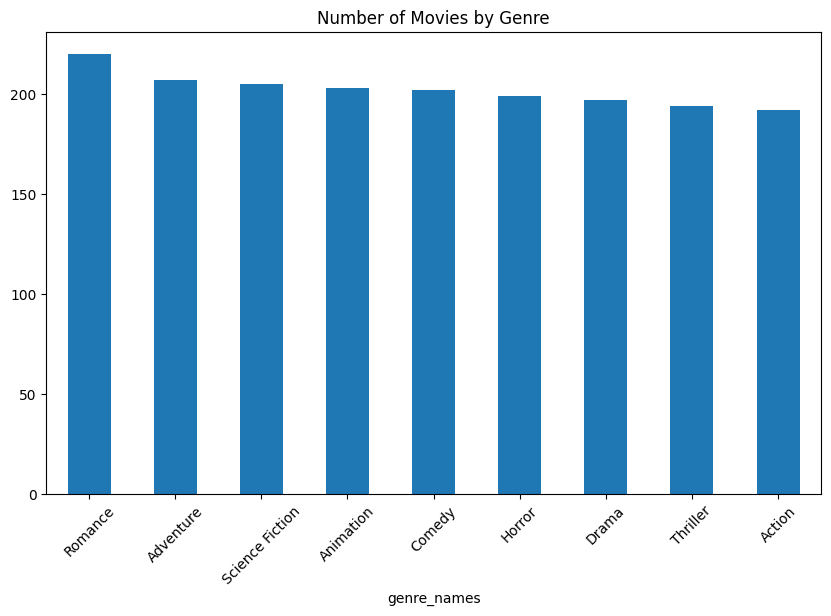

In [10]:
genre_counts = df["genre_names"].explode().value_counts()
plt.figure(figsize=(10,6))
genre_counts.plot(kind="bar")
plt.title("Number of Movies by Genre")
plt.xticks(rotation=45)
plt.show()

### Success Rate by Genre

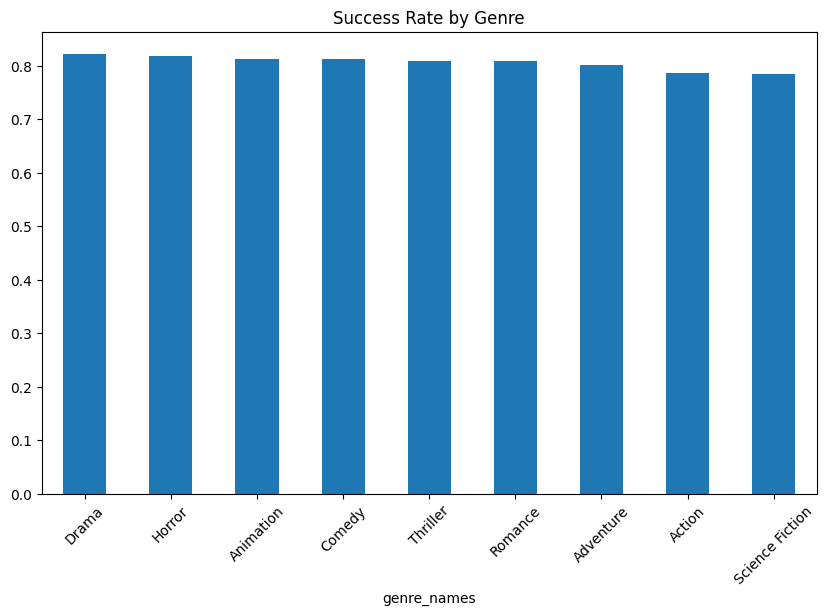

In [11]:
genre_success = (df.explode("genre_names").groupby("genre_names")["success"].mean()
                 .sort_values(ascending=False))
plt.figure(figsize=(10,6))
genre_success.plot(kind="bar")
plt.title("Success Rate by Genre")
plt.xticks(rotation=45)
plt.show()

### Popularity / Runtime / Vote Average vs Success

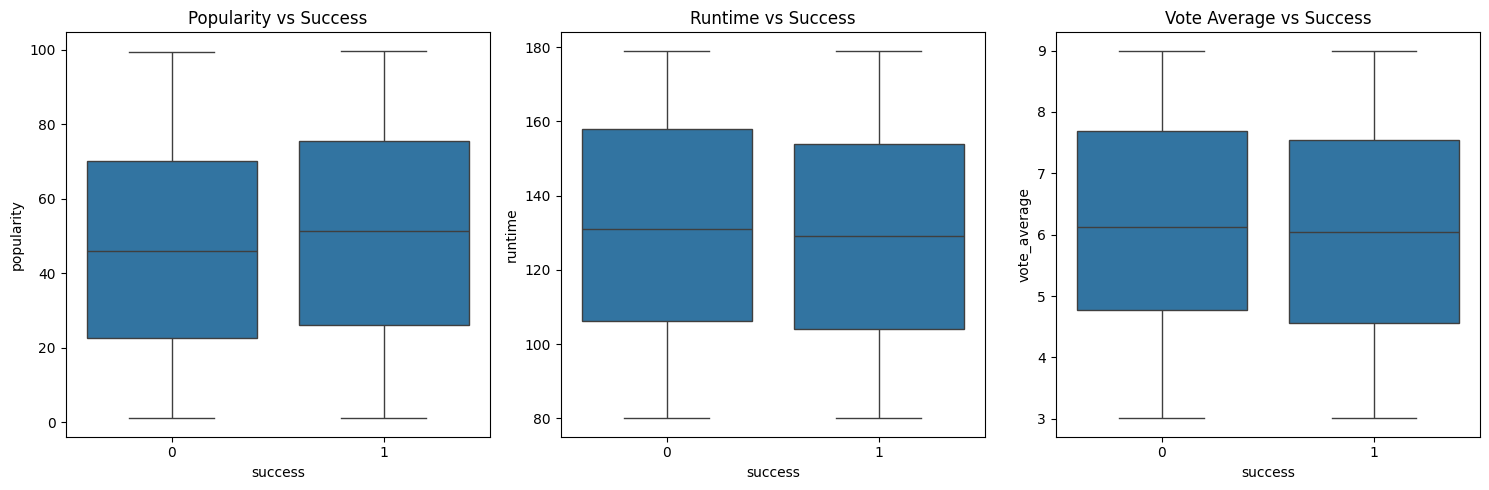

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.boxplot(data=df, x="success", y="popularity", ax=axes[0])
sns.boxplot(data=df, x="success", y="runtime", ax=axes[1])
sns.boxplot(data=df, x="success", y="vote_average", ax=axes[2])
axes[0].set_title("Popularity vs Success")
axes[1].set_title("Runtime vs Success")
axes[2].set_title("Vote Average vs Success")
plt.tight_layout()
plt.show()

### Correlation Heatmap

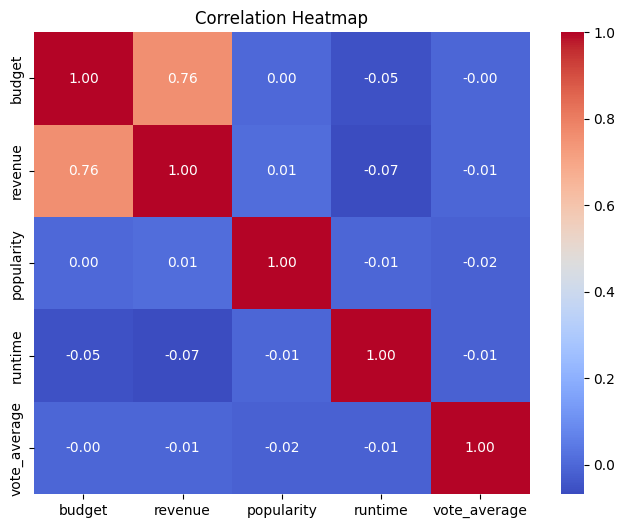

In [13]:
plt.figure(figsize=(8,6))
corr = df[["budget", "revenue", "popularity", "runtime", "vote_average"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Stage 3: Statistical Testing

### T-test: Popularity vs Success

In [14]:
from scipy.stats import ttest_ind

successful = df[df["success"] == 1]["popularity"]
unsuccessful = df[df["success"] == 0]["popularity"]

t_stat, p_value = ttest_ind(successful, unsuccessful)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 2.064684104375536
P-value: 0.03908167189012841


**Interpretation:** p < 0.05 means the difference in average popularity between successful and unsuccessful movies is statistically significant (real, not random noise) — though significance alone doesn't mean the effect is large enough to reliably predict success.

### Chi-Square Test: Genre vs Success

In [15]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df.explode("genre_names")["genre_names"],
    df.explode("genre_names")["success"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 1.735623765256192
P-value: 0.9880720935327683
Degrees of Freedom: 8


**Interpretation:** p ≈ 0.988 — no statistically significant association between genre and success.

## Stage 4: Predictive Modeling (Enhanced)

This section fixes a class-imbalance bug found in the first version of this model (it was always predicting 'success' and getting misleadingly high accuracy), compares multiple models with cross-validation, tunes hyperparameters, and evaluates honestly using ROC-AUC and PR-AUC against a baseline — not just raw accuracy.

### Feature Engineering

In [16]:
from sklearn.preprocessing import MultiLabelBinarizer

# Log-transform budget to reduce right-skew (few blockbusters, many modest budgets)
df["budget_log"] = np.log1p(df["budget"])

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(df["genre_names"]),
    columns=mlb.classes_,
    index=df.index
)

X = pd.concat([df[["budget_log", "popularity", "runtime", "vote_average"]], genre_encoded], axis=1)
y = df["success"]
X.head()

,budget_log,popularity,runtime,vote_average,Action,Adventure,Animation,Comedy,Drama,Horror,Romance,Science Fiction,Thriller
0,17.871721,60.377360,98,6.611888,0,0,0,0,0,0,1,0,0
1,19.073527,86.289857,96,7.184687,0,0,0,0,1,0,0,0,0
2,18.671610,86.995324,148,3.542978,0,0,0,1,0,0,0,0,0
3,18.867285,72.710096,118,5.985176,0,0,0,0,1,0,0,0,0
4,18.816317,74.829585,161,4.578480,0,0,0,1,0,0,0,0,0


### Checking for Leakage: Pre-release-only vs Full Feature Set

`popularity` and `vote_average` are typically measured *after* release. This checks how much they actually add versus features known before release (`budget`, `runtime`, `genres`).

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

prerelease_cols = ["budget_log", "runtime"] + list(genre_encoded.columns)
full_cols = prerelease_cols + ["popularity", "vote_average"]

X_train_pre, X_test_pre, y_train, y_test = train_test_split(
    X[prerelease_cols], y, test_size=0.2, random_state=42, stratify=y)
X_train_full, X_test_full, _, _ = train_test_split(
    X[full_cols], y, test_size=0.2, random_state=42, stratify=y)

rf_pre = RandomForestClassifier(class_weight="balanced", random_state=42).fit(X_train_pre, y_train)
rf_full = RandomForestClassifier(class_weight="balanced", random_state=42).fit(X_train_full, y_train)

print("Pre-release-only AUC:", roc_auc_score(y_test, rf_pre.predict_proba(X_test_pre)[:, 1]))
print("Full-feature AUC:", roc_auc_score(y_test, rf_full.predict_proba(X_test_full)[:, 1]))

Pre-release-only AUC: 0.521872863978127
Full-feature AUC: 0.52589361103293


### Fixing the Class Imbalance Bug

The dataset is ~80.7% success / 19.3% failure. Without `class_weight='balanced'`, the model learned to just always predict 'success' — getting high accuracy while never correctly identifying a single failure. `stratify=y` and `class_weight='balanced'` fix this.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Baseline Comparison (Dummy Classifier)

Before trusting any model's score, establish what "doing nothing smart" looks like.

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_roc_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])
dummy_pr_auc = average_precision_score(y_test, dummy.predict_proba(X_test)[:, 1])

print(f"Baseline -> ROC-AUC: {dummy_roc_auc:.3f}, PR-AUC: {dummy_pr_auc:.3f}")

Baseline -> ROC-AUC: 0.500, PR-AUC: 0.807


### Comparing Models with Cross-Validation

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

for name, m in models.items():
    scores = cross_val_score(m, X, y, cv=cv, scoring="roc_auc")
    print(f"{name}: mean ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression: mean ROC-AUC = 0.484 (+/- 0.034)
Random Forest: mean ROC-AUC = 0.492 (+/- 0.048)
Gradient Boosting: mean ROC-AUC = 0.493 (+/- 0.038)


### Hyperparameter Tuning (Random Forest)

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid, cv=cv, scoring="roc_auc"
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'max_depth': 10, 'n_estimators': 200}


### Final Evaluation — the honest results

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print(f"(Baseline PR-AUC was {dummy_pr_auc:.3f} -- compare against this, not against 0 or 1)")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.795
ROC-AUC: 0.49294358891882106
PR-AUC: 0.824895986109774
(Baseline PR-AUC was 0.807 -- compare against this, not against 0 or 1)

Confusion Matrix:
 [[  5  72]
 [ 10 313]]

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.06      0.11        77
           1       0.81      0.97      0.88       323

    accuracy                           0.80       400
   macro avg       0.57      0.52      0.50       400
weighted avg       0.72      0.80      0.73       400



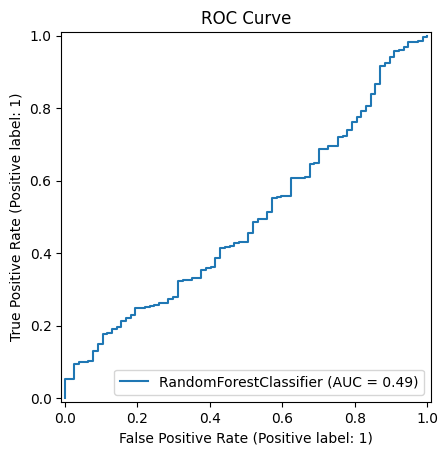

In [23]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

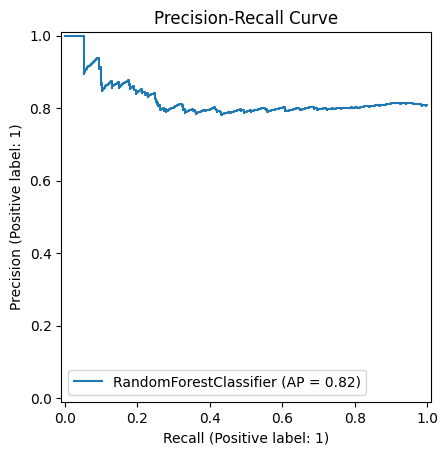

In [24]:
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Precision-Recall Curve")
plt.show()

### Feature Importance

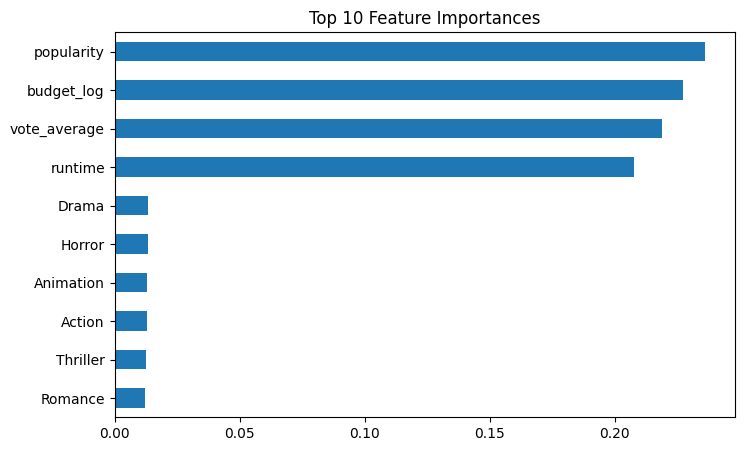

In [25]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
importances.plot(kind="barh", figsize=(8,5))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

### Conclusion

ROC-AUC ≈ 0.49 (roughly equal to the 0.5 baseline for random guessing) shows the model isn't meaningfully separating successful from unsuccessful movies. PR-AUC (0.823) is only marginally above the dummy baseline (0.807) — most of that number comes from the class imbalance itself, not real predictive power.

**Honest takeaway:** budget, runtime, popularity, vote_average, and genre alone don't contain enough signal to reliably predict financial success. The dataset is likely missing the features that actually drive it — marketing spend, star power, franchise status, release-date competition, and pre-release buzz.

## Stage 5: Saving the Final Model

These artifacts are loaded by `app.py` (the Streamlit dashboard) instead of retraining the model every time the app runs.

In [26]:
import joblib

feature_columns = list(X.columns)

joblib.dump(best_model, "movieiq_model.pkl")
joblib.dump(mlb, "movieiq_mlb.pkl")
joblib.dump(feature_columns, "movieiq_features.pkl")
print("Saved: movieiq_model.pkl, movieiq_mlb.pkl, movieiq_features.pkl")

Saved: movieiq_model.pkl, movieiq_mlb.pkl, movieiq_features.pkl
